<hr>

# Welcome to Week 3
### Unsupervised learning

Three clustering algorithms: **KMeans**, **DBSCAN**, and **Hierarchical**. Each demonstrated on handwritten digit data (8x8 pixels, 64 features).
<hr>

#### Clustering Algorithms
Clustering groups data points by similarity — no labels needed.

**Goals:**
- **Minimise intra-distance** (points in same cluster should be close)
- **Maximise inter-distance** (points in different clusters should be far)

<img src="figure/Clustering and its applications image 3.png" style="float: left; margin-right: 10px;" />

### Distance Metrics

| Metric | Formula idea | When to use |
|--------|-------------|-------------|
| **Euclidean** | Straight-line: $\sqrt{\sum(x_i - y_i)^2}$ | Default for most cases |
| **Manhattan** | Absolute differences: $\sum\lvert x_i - y_i \rvert$ | High dimensions, grid data |
| **Cosine** | Angle between vectors: $1 - \frac{x \cdot y}{\lVert x\rVert \lVert y\rVert}$ | Text data |
| **Minkowski** | Generalisation (p=2 → Euclidean, p=1 → Manhattan) | Tunable distance |

We use **Euclidean** throughout. See lecture slides for full formulas.
<hr>

### KMeans
KMeans clusters data into K groups by iteratively assigning points to nearest centroid and updating centroids.

<img src="figure/kmean.png" style="float: left; margin-right: 10px;" />

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn import metrics
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

---
## Part 1: KMeans on Digit Data

In [2]:
# Load digit datasets (each row = 64 pixel features + 1 target label)
digit_zero = pd.read_csv("data/digitData0.csv", header=None)
digit_one = pd.read_csv("data/digitData1.csv", header=None)
print("digit_zero shape:", digit_zero.shape)
print("digit_one  shape:", digit_one.shape)

digit_zero shape: (1549, 65)
digit_one  shape: (1669, 65)


In [3]:
# Combine into a single dataset
Feature_set = pd.concat([digit_zero, digit_one], join="inner")

# Add column headers
cols = ["feature_" + str(i + 1) for i in range(Feature_set.shape[1] - 1)]
cols.append("Target")
Feature_set.columns = cols

print("Combined shape:", Feature_set.shape)
Feature_set.head()

Combined shape: (3218, 65)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,Target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4.0


In [4]:
# Separate features and labels
X = Feature_set.iloc[:, :-1]
y_true = Feature_set.iloc[:, -1]

### Elbow Method

**SSE (Sum of Squared Errors)** = total squared distance from every point to its cluster centre. Lower = tighter clusters, but more K always reduces SSE. The "elbow" is where adding more clusters stops helping much.

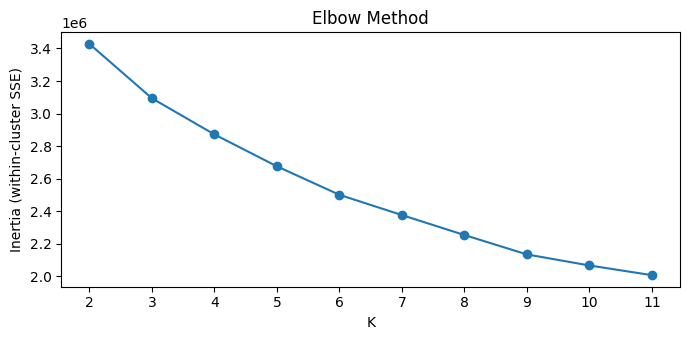

In [5]:
inertias = []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 3.5))
plt.plot(list(K_range), inertias, "o-")
plt.xlabel("K")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Method")
plt.xticks(list(K_range))
plt.tight_layout()
plt.savefig("figure/elbow_method.pdf")
plt.show()

### KMeans with K=2 (intentionally wrong)

The data contains 10 digit classes, so K=2 will produce poor results. This demonstrates why choosing the right K matters.

In [6]:
km2 = KMeans(n_clusters=2, n_init=10, random_state=42)
y_pred = km2.fit_predict(X)

### Purity Score

In [7]:
# Contingency matrix: rows = true classes, columns = predicted clusters
# Each cell = how many points from that true class ended up in that cluster
from sklearn import metrics

y_true_demo = [0, 0, 0, 1, 1, 1, 1]
y_pred_demo = [0, 0, 0, 1, 1, 0, 1]

contingency_matrix = metrics.cluster.contingency_matrix(y_true_demo, y_pred_demo)
print("True labels: ", y_true_demo)
print("Pred clusters:", y_pred_demo)
print()
print("Contingency matrix:")
print("         Cluster0  Cluster1")
for row_idx, row in enumerate(contingency_matrix):
    print(f"  Class{row_idx}:  {row[0]:5d}     {row[1]:5d}")
print()
print("Purity = max of each column, summed, divided by total")
col_max = np.amax(contingency_matrix, axis=0)
print(f"  Column maxes: {col_max}")
print(f"  Purity = {col_max.sum()} / {contingency_matrix.sum()} = {col_max.sum() / contingency_matrix.sum():.3f}")

True labels:  [0, 0, 0, 1, 1, 1, 1]
Pred clusters: [0, 0, 0, 1, 1, 0, 1]

Contingency matrix:
         Cluster0  Cluster1
  Class0:      3         0
  Class1:      1         3

Purity = max of each column, summed, divided by total
  Column maxes: [3 3]
  Purity = 6 / 7 = 0.857


In [8]:
def purity_score(y_true, y_pred):
    """Fraction of points whose cluster is dominated by their true class."""
    contingency_matrix = metrics.cluster.contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)

print("Purity (K=2): %.3f" % purity_score(y_true, y_pred))

Purity (K=2): 0.202


### How to Tell If Clustering Is Good

| Metric | What it actually means | Need real answers? | Score |
|--------|-----------------------|-------------------|-------|
| **Purity** | Each cluster mostly contains one type? | Yes | 1 = pure, 0 = mixed |
| **ARI** | Points that belong together get grouped together? | Yes | 1 = perfect, 0 = random |
| **NMI** | Clustering agrees with real labels? | Yes | 1 = agree, 0 = no clue |
| **Silhouette** | Points closer to own cluster than others? | **No** — no labels needed | 1 = well separated, -1 = wrong cluster |

> **"Need real answers"** = you know the correct grouping (e.g. digit 0 vs digit 1). Real-world data rarely has this, so **Silhouette is the only metric you can always use**.

In [9]:
print(f"Purity:  {purity_score(y_true, y_pred):.3f}")
print(f"ARI:     {adjusted_rand_score(y_true, y_pred):.3f}")
print(f"NMI:     {normalized_mutual_info_score(y_true, y_pred):.3f}")
print(f"Silhouette: {silhouette_score(X, y_pred):.3f}")

Purity:  0.202
ARI:     0.138
NMI:     0.357
Silhouette: 0.119


In [10]:
# Classification report (from teaching material)
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, zero_division=0))

              precision    recall  f1-score   support

         0.0       0.31      0.99      0.47       320
         1.0       0.14      0.94      0.24       327
         2.0       0.00      0.00      0.00       318
         3.0       0.00      0.00      0.00       328
         4.0       0.00      0.00      0.00       323
         5.0       0.00      0.00      0.00       325
         6.0       0.00      0.00      0.00       323
         7.0       0.00      0.00      0.00       320
         8.0       0.00      0.00      0.00       313
         9.0       0.00      0.00      0.00       321

    accuracy                           0.19      3218
   macro avg       0.05      0.19      0.07      3218
weighted avg       0.05      0.19      0.07      3218



> **Why is everything ~0?** `classification_report` compares predicted labels directly with true class labels. But cluster labels are arbitrary — cluster 0 doesn't mean "digit 0". With K=2 and 10 true classes, most classes have no matching cluster. This metric is for **classification** (supervised), not clustering (unsupervised). **Use ARI/NMI instead** for clustering evaluation.

---
## Part 2: Task 1 — KMeans

1. Read  and  and create KMeans clustering.
2. Select the optimum K using Silhouette Coefficient.
3. Find the Mutual Information and Rand Index between predicted and true class.

### Solution: Task 1

In [11]:
# Step 1: Load and prepare data
digit_two = pd.read_csv("data/digitData2.csv", header=None)
digit_three = pd.read_csv("data/digitData3.csv", header=None)

task1_data = pd.concat([digit_two, digit_three], join="inner")
cols = ["feature_" + str(i + 1) for i in range(task1_data.shape[1] - 1)]
cols.append("Target")
task1_data.columns = cols

X_task1 = task1_data.iloc[:, :-1]
y_true_task1 = task1_data.iloc[:, -1]
print("Shape:", task1_data.shape)

Shape: (3221, 65)


In [12]:
# Step 2: Find optimum K using Silhouette Coefficient
silhouette_scores = []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_task1)
    score = silhouette_score(X_task1, labels)
    silhouette_scores.append(score)
    print(f"K={k:2d}  Silhouette: {score:.4f}")

best_k = K_range[np.argmax(silhouette_scores)]
print(f"Best K = {best_k}")

K= 2  Silhouette: 0.1189
K= 3  Silhouette: 0.1280
K= 4  Silhouette: 0.1311
K= 5  Silhouette: 0.1404
K= 6  Silhouette: 0.1556
K= 7  Silhouette: 0.1679
K= 8  Silhouette: 0.1781
K= 9  Silhouette: 0.1939
K=10  Silhouette: 0.1876
K=11  Silhouette: 0.1886
Best K = 9


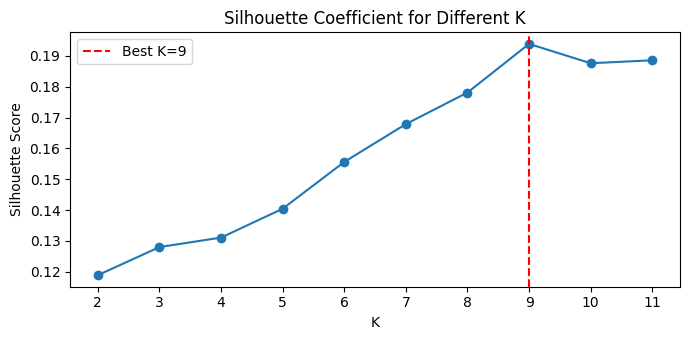

In [13]:
plt.figure(figsize=(7, 3.5))
plt.plot(list(K_range), silhouette_scores, "o-")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Coefficient for Different K")
plt.xticks(list(K_range))
plt.axvline(x=best_k, color="r", linestyle="--", label=f"Best K={best_k}")
plt.legend()
plt.tight_layout()
plt.savefig("figure/task1_silhouette.pdf")
plt.show()

In [14]:
# Step 3: KMeans with best K, compute metrics
km_best = KMeans(n_clusters=best_k, n_init=10, random_state=42)
y_pred_task1 = km_best.fit_predict(X_task1)

print(f"KMeans with K={best_k}")
print(f"  ARI:     {adjusted_rand_score(y_true_task1, y_pred_task1):.4f}")
print(f"  NMI:     {normalized_mutual_info_score(y_true_task1, y_pred_task1):.4f}")
print(f"  Purity:  {purity_score(y_true_task1, y_pred_task1):.4f}")

KMeans with K=9
  ARI:     0.5962
  NMI:     0.7240
  Purity:  0.7302


---
## Part 3: DBSCAN

DBSCAN discovers clusters based on point density. It does not require K in advance and can identify outliers (noise).

| Parameter | Controls | Effect |
|-----------|----------|--------|
| **** | Max neighbour distance | Small → many tiny clusters + noise; Large → fewer big clusters |
| **** | Min points to form a core | Small → more clusters; Large → stricter, fewer clusters |

### Demo: DBSCAN with bad eps

 is far too small for 64-dimensional data — almost everything becomes noise.

In [15]:
from sklearn.cluster import DBSCAN

model_db = DBSCAN(eps=0.3, min_samples=10)
y_pred_db = model_db.fit_predict(X)
print("Purity (eps=0.3): %.3f" % purity_score(y_true, y_pred_db))

Purity (eps=0.3): 0.102


### Task 2 — DBSCAN

1. Read  and  and create DBSCAN clustering.
2. Find the optimum  and .
3. Find the Mutual Information and Rand Index between predicted and true class.

### Solution: Task 2

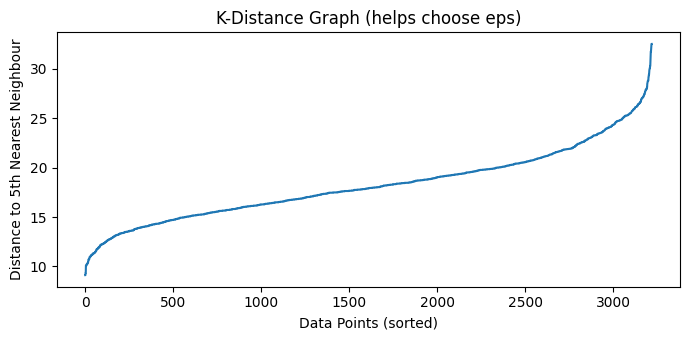

In [16]:
# K-distance graph to estimate eps
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_task1)
distances, _ = nn.kneighbors(X_task1)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7, 3.5))
plt.plot(k_distances)
plt.xlabel("Data Points (sorted)")
plt.ylabel("Distance to 5th Nearest Neighbour")
plt.title("K-Distance Graph (helps choose eps)")
plt.tight_layout()
plt.savefig("figure/task2_kdistance.pdf")
plt.show()

In [17]:
# Grid search over eps and min_samples
eps_values = [5, 10, 15, 20, 25, 30]
min_samples_values = [3, 5, 10]

print(f"{'eps':>5} | {'min_samples':>11} | {'n_clusters':>10} | {'n_noise':>7} | {'Purity':>7} | {'ARI':>7} | {'NMI':>7}")
print("-" * 75)

best_ari = -1
best_params = {}

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        y_pred_db = db.fit_predict(X_task1)
        n_clusters = len(set(y_pred_db)) - (1 if -1 in y_pred_db else 0)
        n_noise = list(y_pred_db).count(-1)

        if n_clusters >= 2:
            ari_db = adjusted_rand_score(y_true_task1, y_pred_db)
            nmi_db = normalized_mutual_info_score(y_true_task1, y_pred_db)
            pur_db = purity_score(y_true_task1, y_pred_db)
            print(f"{eps:5} | {ms:11} | {n_clusters:10} | {n_noise:7} | {pur_db:7.4f} | {ari_db:7.4f} | {nmi_db:7.4f}")
            if ari_db > best_ari:
                best_ari = ari_db
                best_params = {"eps": eps, "min_samples": ms}
        else:
            print(f"{eps:5} | {ms:11} | {n_clusters:10} | {n_noise:7} |  (too few clusters)")

print(f"Best params: eps={best_params.get("eps")}, min_samples={best_params.get("min_samples")}")

SyntaxError: f-string: unmatched '(' (2312941425.py, line 29)

In [ ]:
# DBSCAN with best parameters
db_best = DBSCAN(eps=best_params["eps"], min_samples=best_params["min_samples"])
y_pred_task2 = db_best.fit_predict(X_task1)

n_clusters = len(set(y_pred_task2)) - (1 if -1 in y_pred_task2 else 0)
n_noise = list(y_pred_task2).count(-1)

print(f"DBSCAN with eps={best_params['eps']}, min_samples={best_params['min_samples']}")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points:   {n_noise}")
print(f"  ARI:            {adjusted_rand_score(y_true_task1, y_pred_task2):.4f}")
print(f"  NMI:            {normalized_mutual_info_score(y_true_task1, y_pred_task2):.4f}")
print(f"  Purity:         {purity_score(y_true_task1, y_pred_task2):.4f}")

---
## Part 4: Hierarchical Clustering

Builds a tree of clusters by iteratively merging the closest pairs. The **dendrogram** visualises this hierarchy; cut it at a chosen height to get K clusters.

In [ ]:
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)
    dendrogram(linkage_matrix, **kwargs)

# Build full tree
hc_full = AgglomerativeClustering(distance_threshold=0, linkage="complete", n_clusters=None)
hc_full.fit(X)

plt.figure(figsize=(8, 4))
plt.title("Hierarchical Clustering Dendrogram")
plot_dendrogram(hc_full, truncate_mode="level", p=3)
plt.axhline(y=63, color="r", linestyle="--")
plt.xlabel("Number of points in node (or index if no parenthesis)")
plt.tight_layout()
plt.savefig("figure/dendrogram.pdf")
plt.show()

### Demo: Hierarchical with n_clusters=2

Again intentionally wrong — 10 true classes forced into 2 clusters.

In [ ]:
hc2 = AgglomerativeClustering(linkage="complete", n_clusters=2)
y_pred_hc = hc2.fit_predict(X)
print("Purity (n_clusters=2): %.3f" % purity_score(y_true, y_pred_hc))

### Task 3 — Hierarchical Clustering

1. Read  and  and create Hierarchical clustering.
2. Find the optimum  using Manhattan distance.
3. Find the Mutual Information and Rand Index between predicted and true class.

### Solution: Task 3

With , linkage must be , , or  (not ).

In [ ]:
# Try different n_clusters with manhattan distance
cluster_range = range(2, 12)
results = []

print(f"{"n_clusters":>10} | {"Silhouette":>10} | {"ARI":>7} | {"NMI":>7} | {"Purity":>7}")
print("-" * 60)

for n in cluster_range:
    hc = AgglomerativeClustering(n_clusters=n, metric="manhattan", linkage="complete")
    y_pred_hc = hc.fit_predict(X_task1)
    sil = silhouette_score(X_task1, y_pred_hc)
    ari_hc = adjusted_rand_score(y_true_task1, y_pred_hc)
    nmi_hc = normalized_mutual_info_score(y_true_task1, y_pred_hc)
    pur_hc = purity_score(y_true_task1, y_pred_hc)
    results.append({"n": n, "sil": sil})
    print(f"{n:10} | {sil:10.4f} | {ari_hc:7.4f} | {nmi_hc:7.4f} | {pur_hc:7.4f}")

best_n = max(results, key=lambda x: x["sil"])["n"]
print(f"
Best n_clusters = {best_n}")

In [ ]:
# Hierarchical clustering with best n_clusters
hc_best = AgglomerativeClustering(n_clusters=best_n, metric="manhattan", linkage="complete")
y_pred_task3 = hc_best.fit_predict(X_task1)

print(f"Hierarchical (n_clusters={best_n}, manhattan, complete)")
print(f"  ARI:     {adjusted_rand_score(y_true_task1, y_pred_task3):.4f}")
print(f"  NMI:     {normalized_mutual_info_score(y_true_task1, y_pred_task3):.4f}")
print(f"  Purity:  {purity_score(y_true_task1, y_pred_task3):.4f}")

---
## Quick Q&A

### Q1: How do I choose K?

**Elbow + Silhouette together.**

| Method | How | Pick K at... |
|--------|-----|-------------|
| Elbow (SSE) | Plot inertia vs K | The **bend** — where the curve flattens |
| Silhouette | Plot silhouette score vs K | The **peak** — highest score |

If they disagree, prefer Silhouette. For DBSCAN: tune `eps` via K-distance graph. For Hierarchical: cut dendrogram at longest gap.

---

### Q2: Which metric for choosing K?

**Silhouette** — the only one that works **without labels**. SSE/Elbow is a quick visual check. Purity/ARI/NMI need ground truth.

---

### Q3: How to evaluate clustering results?

**Depends on whether you have ground truth labels (Target column).**

| Have labels? | Metrics to use |
|:---:|--------|
| **No** | Silhouette only |
| **Yes** | ARI, NMI, Purity + `classification_report` (precision, recall, F1) |

In this notebook we **have** the Target column, so we can use all of them.

Note: `classification_report` compares cluster labels directly with class labels. If cluster 0 happens to match class 0, the scores will be meaningful. If not (e.g. cluster 0 contains mostly digit 7), the scores will look wrong — that's expected, not a bug.

---

### Q4: KMeans vs DBSCAN vs Hierarchical?

| Algorithm | Best for | Needs K? | Handles noise? |
|-----------|---------|:---:|:---:|
| **KMeans** | Round, equal-size clusters | Yes | No |
| **DBSCAN** | Irregular shapes, noisy data | No | Yes |
| **Hierarchical** | Exploring cluster hierarchy | Optional | No |

---

### Q5: Why does K=2 give bad results?

10 digit classes into 2 bins → purity ≈ 0.2 (random).

---

### Q6: What does "converged" mean?

Centroids stopped moving → assignments stopped changing. Usually 5–20 iterations.


---
## End of Week 3